# **03 Programazioa** - Ariketa SOLUZIOAK

Koaderno honetan Machine Learning eta API garapenerako oinarriak landuko ditugu 6 atal ezberdinetan.

## Setup (Datuen sorkuntza)
Exekutatu beheko gelaxka `data` karpeta eta beharrezko fitxategiak sortzeko.

In [1]:
import os
import pandas as pd
from sklearn.datasets import make_classification

os.makedirs('data', exist_ok=True)
X, y = make_classification(n_samples=2000, n_features=20, n_classes=2, weights=[0.9, 0.1], random_state=42)
df = pd.DataFrame(X, columns=[f'feature_{i}' for i in range(20)])
df['target'] = y
df.to_csv('data/dataset.csv', index=False)
print("✅ Datuak ondo sortu eta 'data/dataset.csv' fitxategian gorde dira!")

# Imports comunes para las soluciones propias.
import joblib
import numpy as np
from pydantic import BaseModel, ValidationError, field_validator
from typing import List
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler


✅ Datuak ondo sortu eta 'data/dataset.csv' fitxategian gorde dira!


## 1. Atala: Scikit-Learn Banaketa eta Isuria (Split-Leakage)


### APUNTEETAKO ARIKETAK

**Ariketa1.1**, 5. orrialdea

Egoera: Datu-multzo klasiko bat (`load_wine` edo `load_iris`) eskura. Eginkizuna: Idatzi bost urratseko eskema osoa, baina `KNeighborsClassifier` ordez `LogisticRegression` erabili. `test_size=0.3` jarri eta begiratu zehaztasuna nola aldatzen den.

Hausnartu: zergatik `transform` soilik test-datuetan?

In [2]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Flujo completo con un conjunto clásico de scikit-learn.
X, y = load_wine(return_X_y=True)
X_train_wine, X_test_wine, y_train_wine, y_test_wine = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler_wine = StandardScaler()
X_train_wine_scaled = scaler_wine.fit_transform(X_train_wine)
X_test_wine_scaled = scaler_wine.transform(X_test_wine)
model_wine = LogisticRegression(max_iter=1000)
model_wine.fit(X_train_wine_scaled, y_train_wine)
print(f'Wine accuracy: {accuracy_score(y_test_wine, model_wine.predict(X_test_wine_scaled)):.3f}')


Wine accuracy: 0.981


**Hausnarketa (Ariketa 1.1):**

- `test_size=0.3`-rekin (124 train-lagin, 54 test-lagin) **Wine accuracy: 0.981** lortu da; `test_size=0.2`-rekin (142/36) 0.972 zen. Test-multzoa handitzeak ebaluazioa egonkorragoa egiten du, baina train-multzoa txikitzen du.
- Test-multzoan `transform` soilik erabiltzen da (`fit_transform` ordez), eskalatzailearen estatistikoak (batazbestekoa, desbideratzea) **soilik train-datuetatik** ikas daitezen. Test-datuak `fit`-ean sartuz gero, informazio-ihesa (*leakage*) gertatzen da eta zehaztasuna puztuta agertzen da.


**Ariketa 1.2**, 8. orrialdea

Egoera: Salmenta-datu-base bat: produktua (kategorikoa), prezioa (zenbakizkoa), eskualdea (kategorikoa), stock (zenbakizkoa, batzuk falta). Erabaki zer estrategia (`mean/median/most_frequent`) erabili stock faltadunarentzat eta arrazoitu.  

Eginkizuna: Diseinatu `ColumnTransformer` egokia. Erabaki imputazio-estrategia stock-erako. Eztabaidatu eskualdearen kodeketa: `OneHotEncoder` ala `OrdinalEncoder`?

In [3]:
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

# Adibide-datuak eta preprocessing pipeline.
np.random.seed(0)
df = pd.DataFrame({
    'produktua': np.random.choice(['A', 'B', 'C', 'D'], 200),
    'prezioa': np.random.uniform(5, 500, 200),
    'eskualdea': np.random.choice(['Bilbo', 'Donostia', 'Gasteiz', 'Iruña'], 200),
    'stock': np.random.randint(0, 200, 200).astype(float),
})
df.loc[np.random.choice(df.index, 25), 'stock'] = np.nan
numeric_features = ['prezioa', 'stock']
categorical_features = ['produktua', 'eskualdea']
preprocessor = ColumnTransformer([
    ('numeric', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
    ]), numeric_features),
    ('categorical', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore')),
    ]), categorical_features),
])
preprocessed = preprocessor.fit_transform(df)
print(f'Preprocessed shape: {preprocessed.shape}')


Preprocessed shape: (200, 10)


**Arrazoiketa (Ariketa 1.2):**

- `stock`: `median` imputazioa aukeratu da. Medianak, `mean`-ek ez bezala, balio muturreko eta banaketa alboratuekiko sendoa da, stock-kopuruetan ohikoak direnak; bestela outlier bakar batek imputatutako balio guztiak desitxuratzen ditu.
- `eskualdea`: aldagai nominala da, ordenarik gabea (Bilbo/Donostia/Gasteiz/Iruña); horregatik `OneHotEncoder` da egokia. `OrdinalEncoder`-ek hurrenkera faltsu bat inposatuko luke eta ereduak existitzen ez den ordena-erlazio bat ikasiko luke. Hurrenkera erreala dagoenean bakarrik (adib. txikia < ertaina < handia) du zentzua `OrdinalEncoder`-ek.


### ARIKETA OSAGARRIAK

**1.1 Ariketa: Datuak Kargatu**

Kargatu `data/dataset.csv` fitxategia Pandas bidez `df` izeneko aldagai batean.

In [4]:
df = pd.read_csv('data/dataset.csv')

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea (EZ UKITU)
assert 'df' in locals(), "'df' aldagaia ez da sortu"
assert type(df) == pd.DataFrame, "'df' ez da Pandas DataFrame bat"
assert df.shape == (2000, 21), "Datuen tamaina ez da zuzena"
print("✅ Zuzena!")

✅ Zuzena!


**1.2 Ariketa: X eta y banatu**
Sortu bi aldagai: `X` (ezaugarri guztiak 'target' izan ezik) eta `y` ('target' zutabea).

In [5]:
X = df.drop(columns='target')
y = df['target']

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert 'X' in locals() and 'y' in locals(), "Aldagaiak falta dira"
assert X.shape == (2000, 20), "X-ren dimentsioak ez dira zuzenak"
assert y.shape == (2000,), "y-ren dimentsioak ez dira zuzenak"
print("✅ Zuzena!")

✅ Zuzena!


**1.3 Ariketa: Train/Test banaketa** Erabili `train_test_split` datuak banatzeko. Train %80 eta Test %20. Erabili `random_state=42`.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert X_train.shape[0] == 1600, "Train multzoa ez da %80"
assert X_test.shape[0] == 400, "Test multzoa ez da %20"
print("✅ Zuzena!")

✅ Zuzena!


**1.4 Ariketa: Data Leakage saihestea (StandardScaler)**
Sortu `StandardScaler` bat. Erabili `.fit_transform()` `X_train` multzoan eta gorde `X_train_scaled` aldagaian. Ondoren erabili `.transform()` `X_test` multzoan eta gorde `X_test_scaled` aldagaian.

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert X_train_scaled.shape == (1600, 20), "Dimentsioak ez daude ondo"
print("✅ Zuzena!")

✅ Zuzena!


**1.5 Ariketa: Egiaztapena**
Egiaztatu `X_train_scaled` barruan lehenengo zutabearen batezbestekoa ia 0 dela.

In [8]:
batezbestekoa = float(np.mean(X_train_scaled[:, 0]))

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert abs(batezbestekoa) < 1e-10, "Batezbestekoa ez dago 0tik oso gertu"
print("✅ Zuzena!")

✅ Zuzena!


## 2. Atala: Metrikak (Accuracy vs Recall)
### 2.1 Ariketa: Logistic Regression
Sortu eta entrenatu `LogisticRegression` eredu bat (`model_lr` aldagaian) `X_train_scaled` eta `y_train` erabiliz.

In [9]:
model_lr = LogisticRegression(max_iter=1000)
model_lr.fit(X_train_scaled, y_train)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert 'model_lr' in locals(), "Eredua ez da sortu"
assert hasattr(model_lr, 'coef_'), "Eredua ez dago entrenatuta"
print("✅ Zuzena!")

✅ Zuzena!


### 2.2 Ariketa: Iragarpenak
Egin iragarpenak `X_test_scaled` erabiliz eta gorde `y_pred` aldagaian.

In [10]:
y_pred = model_lr.predict(X_test_scaled)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert len(y_pred) == 400, "Iragarpenen kopurua ez da 400"
print("✅ Zuzena!")

✅ Zuzena!


### 2.3 Ariketa: Accuracy
Kalkulatu 'Accuracy' (zehaztasuna) eta gorde `acc` aldagaian.

In [11]:
acc = accuracy_score(y_test, y_pred)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert 0 <= acc <= 1, "Accuracy balioa ez da zuzena"
print(f"✅ Zuzena! Accuracy = {acc:.4f}")

✅ Zuzena! Accuracy = 0.9325


### 2.4 Ariketa: Recall
Kalkulatu 'Recall' (estaldura) eta gorde `rec` aldagaian.

In [12]:
rec = recall_score(y_test, y_pred)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert 0 <= rec <= 1, "Recall balioa ez da zuzena"
print(f"✅ Zuzena! Recall = {rec:.4f}")

✅ Zuzena! Recall = 0.6098


### 2.5 Ariketa: Confusion Matrix
Sortu nahasmen-matrizea (`cm` aldagaian) `confusion_matrix` erabiliz.

In [13]:
cm = confusion_matrix(y_test, y_pred, labels=[0, 1])

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert cm.shape == (2, 2), "Matrizeak 2x2 izan behar du"
print(f"✅ Zuzena!\n{cm}")

✅ Zuzena!
[[348  11]
 [ 16  25]]


## 3. Atala: Klase Desorekatuak
### 3.1 Ariketa: Klaseen Banaketa
Erabili `.value_counts()` `y_train` aldagaian train multzoko klaseen banaketa ikusteko (`counts` aldagaian gorde).

In [14]:
counts = y_train.value_counts().sort_index()

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert len(counts) == 2, "Bi klase egon beharko lirateke"
print(f"✅ Zuzena!\n{counts}")

✅ Zuzena!
target
0    1434
1     166
Name: count, dtype: int64


### 3.2 Ariketa: Eredu Orekatu bat entrenatu
Sortu `LogisticRegression` berri bat (`model_balanced`) `class_weight='balanced'` argumentuarekin, eta entrenatu.

In [15]:
model_balanced = LogisticRegression(class_weight='balanced', max_iter=1000)
model_balanced.fit(X_train_scaled, y_train)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert model_balanced.class_weight == 'balanced', "class_weight ez da 'balanced'"
print("✅ Zuzena!")

✅ Zuzena!


### 3.3 Ariketa: Konparatu Recall-ak
Egin iragarpenak eredu berriarekin eta kalkulatu recall berria (`rec_balanced`).

In [16]:
y_pred_balanced = model_balanced.predict(X_test_scaled)
rec_balanced = recall_score(y_test, y_pred_balanced)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert rec_balanced > rec, "Normalean recall-ak hobea izan beharko luke orekatzerakoan!"
print(f"✅ Zuzena! Aurrekoa: {rec:.4f} -> Orekatu ondoren: {rec_balanced:.4f}")

✅ Zuzena! Aurrekoa: 0.6098 -> Orekatu ondoren: 0.8049


### 3.4 Ariketa: Random Forest

Orain probatu `RandomForestClassifier` batekin (`rf_balanced`), `class_weight='balanced_subsample'` erabiliz. Egin iragarpenak eta kalkulatu bere recall-a (`rec_rf_balanced`).

In [17]:
rf_balanced = RandomForestClassifier(class_weight='balanced_subsample', random_state=42)
rf_balanced.fit(X_train_scaled, y_train)
rf_pred_balanced = rf_balanced.predict(X_test_scaled)
rec_rf_balanced = recall_score(y_test, rf_pred_balanced)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert rf_balanced.class_weight == 'balanced_subsample', "Ez duzu class_weight egokia erabili"
print(f"✅ Zuzena! RF Recall (0.5 atalasea): {rec_rf_balanced:.4f}")

✅ Zuzena! RF Recall (0.5 atalasea): 0.6341


### 3.5 Ariketa: Datu sintetikoak (SMOTE) eta Eredu Berria
`class_weight` erabiltzeaz gain, datu-multzoa fisikoki orekatu dezakegu SMOTE erabiliz. Sortu `X_train_smote` eta `y_train_smote`.

In [18]:
from imblearn.over_sampling import SMOTE

sm = SMOTE(random_state=42)
X_train_smote, y_train_smote_array = sm.fit_resample(X_train_scaled, y_train)
y_train_smote = pd.Series(y_train_smote_array, name=y_train.name)

# Balioztatzea (jatorrizko ariketatik)
assert y_train_smote.value_counts()[0] == y_train_smote.value_counts()[1], "Klaseak ez daude orekatuta!"
print(f"✅ Zuzena! SMOTE datuak sortu dira: {len(y_train_smote)} lagin")


✅ Zuzena! SMOTE datuak sortu dira: 2868 lagin


### 3.6 Ariketa: Egiaztatu Random Forest Recall-a
 Entrenatu `RandomForestClassifier` berri bat (`rf_smote`) datu berri hauekin (ez da beharrezkoa `class_weight` erabiltzea datuak jada orekatuta daudelako). Kalkulatu bere jatorrizko recall-a (`rec_rf_smote`).

In [19]:
rf_smote = RandomForestClassifier(random_state=42)
rf_smote.fit(X_train_smote, y_train_smote)
y_pred_smote = rf_smote.predict(X_test_scaled)
rec_rf_smote = recall_score(y_test, y_pred_smote)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert rec_rf_smote > 0, "Eredua ez da ondo entrenatu!"
print(f"✅ Zuzena! SMOTE RF Recall (0.5 atalasea): {rec_rf_smote:.4f}")


✅ Zuzena! SMOTE RF Recall (0.5 atalasea): 0.7317



### 3.7 Ariketa: Precision-Recall grafikoa
Marraztu kurbak ikusteko zergatik aldatuko dugun atalasea. Erabili `precision_recall_curve` funtzioa `y_test` eta `y_prob` erabiliz, eta marraztu Precision eta Recall `thresholds` (atalase) desberdinen arabera.



> Oharra: Behatu grafikoa hurrengo ariketan zein atalase erabili erabakitzeko.







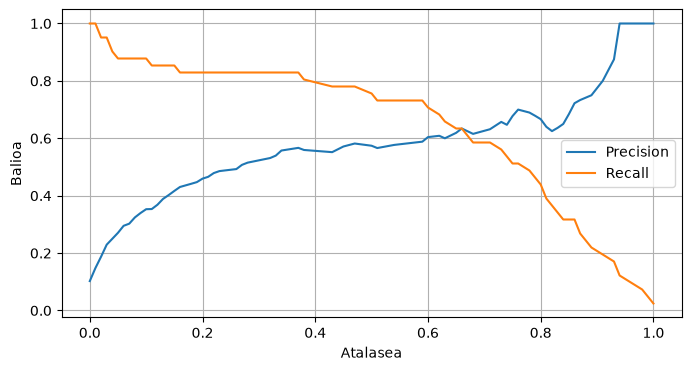

✅ Zuzena! Grafikoari esker, atalase egokia non dagoen ikus dezakegu.


In [20]:
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

y_prob = rf_smote.predict_proba(X_test_scaled)[:, 1]
precisions, recalls, thresholds = precision_recall_curve(y_test, y_prob)
plt.figure(figsize=(8, 4))
plt.plot(thresholds, precisions[:-1], label='Precision')
plt.plot(thresholds, recalls[:-1], label='Recall')
plt.xlabel('Atalasea')
plt.ylabel('Balioa')
plt.legend()
plt.grid(True)
plt.show()

# Balioztatzea (jatorrizko ariketatik)
print("✅ Zuzena! Grafikoari esker, atalase egokia non dagoen ikus dezakegu.")


### 3.8 Ariketa: Atalasearen Doikuntza (predict_proba)
Erabili rf_smote.predict_proba() probabilitateak ateratzeko (bigarren zutabea), eta sortu y_pred_doitua iragarpen berri bat probabilitatea > 0.30 jarririk. Kalkulatu Recall berria (rec_doitua).

In [21]:
y_pred_doitua = (y_prob > 0.30).astype(int)
from sklearn.metrics import classification_report
rec_doitua = recall_score(y_test, y_pred_doitua)
print('Atalase berriaren (0.30) ebaluazioa:')
print(classification_report(y_test, y_pred_doitua))

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert rec_doitua >= rec_rf_smote, "Atalasea jaistean Recall-ak igo edo mantendu egin behar du!"
print(f"✅ Zuzena! Jatorrizko SMOTE Recall: {rec_rf_smote:.4f} -> Doitua (0.30): {rec_doitua:.4f}")


Atalase berriaren (0.30) ebaluazioa:
              precision    recall  f1-score   support

           0       0.98      0.92      0.95       359
           1       0.53      0.83      0.65        41

    accuracy                           0.91       400
   macro avg       0.76      0.87      0.80       400
weighted avg       0.93      0.91      0.92       400

✅ Zuzena! Jatorrizko SMOTE Recall: 0.7317 -> Doitua (0.30): 0.8293


## 4. Atala: Hiperparametroen Doiketa

### 4.1 Ariketa: GridSearchCV
Sortu `param_grid` bat `RandomForestClassifier`entzat (`n_estimators: [50, 100], max_depth: [None, 5]`). Erabili `GridSearchCV` eredu onena aurkitzeko.

In [22]:
param_grid = {'n_estimators': [50, 100], 'max_depth': [None, 5]}
grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=3, scoring='accuracy')
grid_search.fit(X_train_scaled, y_train)
best_model = grid_search.best_estimator_

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert best_model is not None, "GridSearchCV ez da ondo exekutatu"
print(f"✅ Zuzena! Eredu onena aurkitu da.")

✅ Zuzena! Eredu onena aurkitu da.


## 5. Atala: Pipeline eta Joblib


### 5.1 Ariketa: Pipeline-a sortu
Sortu `Pipeline` bat bi pausorekin: 1) `StandardScaler` ('scaler') eta 2) `RandomForestClassifier(class_weight='balanced')` ('classifier'). Gorde `pipeline` aldagaian.

In [23]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42)),
])

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert len(pipeline.steps) == 2, "Pipeline-ak bi pauso eduki behar ditu"
assert 'scaler' in pipeline.named_steps, "Ez dago 'scaler' pausorik"
assert 'classifier' in pipeline.named_steps, "Ez dago 'classifier' pausorik"
print("✅ Zuzena!")

✅ Zuzena!


### 5.2 Ariketa: Pipeline-a entrenatu
Entrenatu `pipeline` zuzenean *datu gordinekin* (`X_train` eta `y_train`), Pipelineak berak egingo baitu eskalatzea barnean.

In [24]:
pipeline.fit(X_train, y_train)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert hasattr(pipeline, 'classes_'), "Pipeline ez dago entrenatuta"
print("✅ Zuzena!")

✅ Zuzena!


### 5.3 Ariketa: Pipeline Iragarpenak
Egin iragarpena `X_test` (gordina) erabiliz eta kalkulatu Accuracy (`pipe_acc`).

In [25]:
pipe_acc = accuracy_score(y_test, pipeline.predict(X_test))

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert 0 <= pipe_acc <= 1, "Accuracy okerra da"
print(f"✅ Zuzena! Pipeline Accuracy = {pipe_acc:.4f}")

✅ Zuzena! Pipeline Accuracy = 0.9275


### 5.4 Ariketa: Eredua Gorde
Erabili `joblib.dump` liburutegia entrenatutako `pipeline` eredua `data/eredua.pkl` fitxategian gordetzeko.

In [26]:
joblib.dump(pipeline, 'data/eredua.pkl')

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert os.path.exists('data/eredua.pkl'), "Eredua ez da fitxategian aurkitu"
print("✅ Zuzena!")

✅ Zuzena!


### 5.5 Ariketa: Eredua Kargatu
Erabili `joblib.load` eredua disko batetik kargatzeko (`eredu_kargatua`), eta frogatu testeko lehen instantziarekin iragarpena egiten.

In [27]:
eredu_kargatua = joblib.load('data/eredua.pkl')
iragarpen_1 = eredu_kargatua.predict(X_test.iloc[[0]])

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert iragarpen_1[0] in [0, 1], "Iragarpena ez da klase logikoa"
print(f"✅ Zuzena! Lehenengo instantziaren iragarpena: {iragarpen_1[0]}")

✅ Zuzena! Lehenengo instantziaren iragarpena: 0


## 6. Atala: Pydantic eta API Eskemak


### 6.1 Ariketa: Request Eskema
Sortu `PredictionRequest` Pydantic `BaseModel` bat. `features` izeneko lista bat izango du, `float` motako elementuekin (`List[float]`).

In [28]:
class PredictionRequest(BaseModel):
    features: List[float]

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert issubclass(PredictionRequest, BaseModel), "Ez da BaseModel-etik heredatzen"
print("✅ Zuzena!")

✅ Zuzena!


### 6.2 Ariketa: Balioztatze pertsonalizatua (@field_validator)
Berridatzi eredua: gehitu `@field_validator('features')` funtzio bat, listaren luzera zehazki 20 ez bada `ValueError` bat jaurtitzeko.

In [29]:
class PredictionRequest(BaseModel):
    features: List[float]

    @field_validator('features')
    @classmethod
    def validar_longitud(cls, values: List[float]) -> List[float]:
        if len(values) != 20:
            raise ValueError('Se necesitan exactamente 20 características')
        return values

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea (hurrengo ariketan egingo da)
print("✅ Zuzena!")

✅ Zuzena!


### 6.3 Ariketa: Error kudeaketa (ValidationError)
Sortu instantzia bat 3 elementurekin soilik, eta erabili `try/except ValidationError` bloke bat errorea ondo harrapatzeko eta mezua inprimatzeko.

In [30]:
errorea_dago = False
try:
    PredictionRequest(features=[0.0, 0.0, 0.0])
except ValidationError as error:
    errorea_dago = True
    print(error)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert errorea_dago, "Errorea ez da jaurti eta harrapatu ValidationError bezala"
print("\n✅ Zuzena! Errorea ondo harrapatu da.")

1 validation error for PredictionRequest
features
  Value error, Se necesitan exactamente 20 características [type=value_error, input_value=[0.0, 0.0, 0.0], input_type=list]
    For further information visit https://errors.pydantic.dev/2.13/v/value_error

✅ Zuzena! Errorea ondo harrapatu da.


### 6.4 Ariketa: Response Eskema
Sortu `PredictionResponse` BaseModel bat, `klasea` (int) eta `probabilitatea` (float) eremuekin.

In [31]:
class PredictionResponse(BaseModel):
    klasea: int
    probabilitatea: float

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
assert issubclass(PredictionResponse, BaseModel), "Ez da BaseModel"
print("✅ Zuzena!")

✅ Zuzena!


### 6.5 Ariketa: API funtzio simulatua
Sortu `egin_iragarpena(req: PredictionRequest) -> PredictionResponse` funtzio bat. Funtzio horrek `eredu_kargatua` erabiliko du `req.features` bektorea iragartzeko (gogoratu 2D array gisa pasa behar dela sklearn-era) eta erantzuna itzuliko du.

In [32]:
def egin_iragarpena(req: PredictionRequest) -> PredictionResponse:
    features = pd.DataFrame([req.features], columns=X_train.columns)
    klasea = int(eredu_kargatua.predict(features)[0])
    probabilitatea = float(eredu_kargatua.predict_proba(features)[0, 1])
    return PredictionResponse(klasea=klasea, probabilitatea=probabilitatea)

req_test = PredictionRequest(features=[0.0] * 20)
resp = egin_iragarpena(req_test)

# Balioztatzea (jatorrizko ariketatik)
# Balioztatzea
req_test = PredictionRequest(features=[0.0]*20)
resp = egin_iragarpena(req_test)
assert isinstance(resp, PredictionResponse), "Ez du PredictionResponse bat itzuli"
print(f"✅ Zuzena! Test erantzuna: {resp.model_dump()}")

✅ Zuzena! Test erantzuna: {'klasea': 0, 'probabilitatea': 0.1}
